In [30]:
print("all ok")

all ok


In [31]:
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

print("Project root added to path:", project_root)

Project root added to path: d:\gen ai projects\langchain and its projects\automated-research-report-generation


In [32]:
from research_and_analyst.utils.model_loader import ModelLoader

In [33]:
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage
from langgraph.checkpoint.memory import MemorySaver

In [34]:
model_loader = ModelLoader()

{"timestamp": "2026-04-09T09:18:55.822099Z", "level": "info", "event": "Initializing ApiKeyManager"}
{"timestamp": "2026-04-09T09:18:55.823383Z", "level": "info", "event": "OPENAI_API_KEY loaded successfully from environment"}
{"timestamp": "2026-04-09T09:18:55.825790Z", "level": "info", "event": "GOOGLE_API_KEY loaded successfully from environment"}
{"timestamp": "2026-04-09T09:18:55.826789Z", "level": "info", "event": "GROQ_API_KEY loaded successfully from environment"}
{"path": "D:\\gen ai projects\\langchain and its projects\\automated-research-report-generation\\research_and_analyst\\config\\configuration.yaml", "keys": ["astra_db", "embedding_model", "retriever", "llm"], "timestamp": "2026-04-09T09:18:55.834570Z", "level": "info", "event": "Configuration loaded successfully"}
{"config_keys": ["astra_db", "embedding_model", "retriever", "llm"], "timestamp": "2026-04-09T09:18:55.836640Z", "level": "info", "event": "YAML configuration loaded successfully"}


In [35]:
llm = model_loader.load_llm()

{"provider": "openai", "model": "gpt-4o", "timestamp": "2026-04-09T09:18:56.729839Z", "level": "info", "event": "Loading LLM"}
{"provider": "openai", "model": "gpt-4o", "timestamp": "2026-04-09T09:18:56.738920Z", "level": "info", "event": "LLM loaded successfully"}


In [36]:
llm.invoke("hi").content

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


'Hello! How can I assist you today?'

In [37]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

In [38]:
class Analyst(BaseModel):
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, concerns, and motives.")
    
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"
    

In [39]:
analyst = Analyst(
    name="vikas jangid",
    role="genai eng",
    affiliation="AI research Lab",
    description="I am a genai eng as well as mentor"
)

In [40]:
print(analyst.name)

vikas jangid


In [41]:
print(analyst.persona)

Name: vikas jangid
Role: genai eng
Affiliation: AI research Lab
Description: I am a genai eng as well as mentor



In [42]:

class Perspectives(BaseModel):
       analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [43]:
class GenerateAnalystState(TypedDict):
    topic: str
    max_analysts: int
    human_analyst_feedback: str
    analysts: List[Analyst]

In [46]:

Analyst(
        name="Dr. Neha Patel",
        role="Medical Data Scientist",
        affiliation="Stanford Medicine",
        description="Focuses on predictive models for patient outcomes."
    ),

(Analyst(name='Dr. Neha Patel', role='Medical Data Scientist', affiliation='Stanford Medicine', description='Focuses on predictive models for patient outcomes.'),)

In [47]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [48]:
def create_analyst(state: GenerateAnalystState):
    """it is creating my analyst"""
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback","")

    structured_llm=llm.with_structured_output(Perspectives)

    system_message=analyst_instructions.format(topic=topic,
                                max_analysts=max_analysts,
                                human_analyst_feedback=human_analyst_feedback)
    
    analysts=structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content="Generate the set of analysts")])

    return {"analysts": analysts.analysts}




In [49]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 2,
    'human_analyst_feedback': 'give the real info'}
    )

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Emily Chen', role='Public Health Analyst', affiliation='World Health Organization', description='Dr. Emily Chen focuses on global health trends, particularly the impact of pandemics on public health systems. Her primary concern is understanding how health policies can be optimized to improve resilience against future health crises. She is motivated by the need to ensure equitable access to healthcare resources worldwide.'),
  Analyst(name='Dr. Raj Patel', role='Nutrition and Lifestyle Researcher', affiliation='Harvard T.H. Chan School of Public Health', description='Dr. Raj Patel specializes in the intersection of nutrition, lifestyle, and chronic disease prevention. His research is centered on how dietary patterns and physical activity influence long-term health outcomes. He is driven by the goal of reducing the prevalence of lifestyle-related diseases through evidence-based interventions and public education.')]}

In [ ]:
def human_feedback(state):
    """no output node that should be intrupted on"""
    pass

In [61]:
def should_continue(state):
    """Return the next node to execute"""
    human_analyst_feedback = state.get("human_analyst_feedback", None)
    if human_analyst_feedback:
        return "create_analyst"

In [71]:
from IPython.display import Image, display

In [72]:
builder=StateGraph(GenerateAnalystState)

In [73]:
builder.add_node("create_analyst",create_analyst)
builder.add_node("human_feedback",human_feedback)


In [ ]:
# builder.add_node("should_continue",should_continue)

In [74]:
builder.add_edge(START,"create_analyst")
builder.add_edge("create_analyst","human_feedback")
builder.add_conditional_edges("human_feedback",
                          should_continue,
                          ["create_analyst",
                           END])

In [75]:
memory = MemorySaver()

In [76]:
graph=builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)

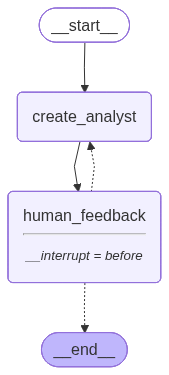

In [77]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [78]:
topic = "the benifits of adopting langgraph as an agent framework"


In [79]:
max_analysts = 4

In [80]:
thread = {"configurable":{"thread_id":1}}

In [81]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Emily Chen
Affiliation: Institute of Advanced AI Systems
Role: AI Framework Researcher
Description: Dr. Chen focuses on the comparative analysis of AI frameworks, with a particular interest in how LangGraph enhances agent-based systems. Her research examines the scalability and flexibility of LangGraph in various applications, aiming to identify its unique advantages over traditional frameworks.
--------------------------------------------------
Name: Raj Patel
Affiliation: Tech Innovators Inc.
Role: Software Developer
Description: Raj is a software developer specializing in AI-driven applications. He is interested in the practical implementation of LangGraph, exploring how its adoption can streamline development processes and improve the efficiency of AI agents. Raj is particularly focused on the framework's impact on reducing development time and increasing code maintainability.
--------------------------------------------------
Name: Dr. Sarah Thompson
Affiliation: Global 

In [83]:
state=graph.get_state(thread)
state

StateSnapshot(values={'topic': 'the benifits of adopting langgraph as an agent framework', 'max_analysts': 4, 'analysts': [Analyst(name='Dr. Emily Chen', role='AI Framework Researcher', affiliation='Institute of Advanced AI Systems', description='Dr. Chen focuses on the comparative analysis of AI frameworks, with a particular interest in how LangGraph enhances agent-based systems. Her research examines the scalability and flexibility of LangGraph in various applications, aiming to identify its unique advantages over traditional frameworks.'), Analyst(name='Raj Patel', role='Software Developer', affiliation='Tech Innovators Inc.', description="Raj is a software developer specializing in AI-driven applications. He is interested in the practical implementation of LangGraph, exploring how its adoption can streamline development processes and improve the efficiency of AI agents. Raj is particularly focused on the framework's impact on reducing development time and increasing code maintainab

In [84]:
state.next

('human_feedback',)

In [85]:
graph.update_state(thread,
                   {"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f133fa4-af4d-6abf-8002-7067289d4adf'}}

In [86]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Emily Chen
Affiliation: Institute of Advanced AI Systems
Role: AI Framework Researcher
Description: Dr. Chen focuses on the comparative analysis of AI frameworks, with a particular interest in how LangGraph enhances agent-based systems. Her research examines the scalability and flexibility of LangGraph in various applications, aiming to identify its unique advantages over traditional frameworks.
--------------------------------------------------
Name: Raj Patel
Affiliation: Tech Innovators Inc.
Role: Software Developer
Description: Raj is a software developer specializing in AI-driven applications. He is interested in the practical implementation of LangGraph, exploring how its adoption can streamline development processes and improve the efficiency of AI agents. Raj is particularly focused on the framework's impact on reducing development time and increasing code maintainability.
--------------------------------------------------
Name: Dr. Sarah Thompson
Affiliation: Global 

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Emily Chen
Affiliation: Global Tech Solutions
Role: Enterprise Technology Strategist
Description: Dr. Chen focuses on the strategic implementation of cutting-edge technologies within large enterprises. Her primary concern is how adopting LangGraph as an agent framework can enhance operational efficiency and drive innovation in enterprise applications. She is particularly interested in the scalability and integration capabilities of LangGraph in complex IT environments.
--------------------------------------------------
Name: Raj Patel
Affiliation: Innovate Ventures
Role: Startup Ecosystem Analyst
Description: Raj Patel analyzes trends and opportunities within the startup ecosystem. He is interested in how LangGraph can provide startups with a competitive edge by enabling rapid development and deployment of intelligent agents. His focus is on cost-effectiveness, ease of use, and the potential for LangGraph to support innovative business models in early-stage companies.
-------